In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
df = pd.read_csv("kidney_disease.csv")
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
important_columns = ['age', 'bp', 'sg', 'al', 'hemo', 'sc', 'htn', 'dm', 'cad', 'appet', 'pc', 'classification']
df = df[important_columns].copy()
df.head()

,age,bp,sg,al,hemo,sc,htn,dm,cad,appet,pc,classification
0,48.0,80.0,1.020,1.0,15.4,1.2,yes,yes,no,good,normal,ckd
1,7.0,50.0,1.020,4.0,11.3,0.8,no,no,no,good,normal,ckd
2,62.0,80.0,1.010,2.0,9.6,1.8,no,yes,no,poor,normal,ckd
3,48.0,70.0,1.005,4.0,11.2,3.8,yes,no,no,poor,abnormal,ckd
4,51.0,80.0,1.010,2.0,11.6,1.4,no,no,no,good,normal,ckd


In [5]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [6]:
for col in ['age', 'bp', 'hemo', 'sc']:
    df[col].fillna(df[col].median(), inplace=True)
for col in ['sg', 'al']:
    df[col].fillna(df[col].mode()[0], inplace=True)


for col in ['htn', 'dm', 'cad', 'appet', 'pc']:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19956\24022119.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19956\24022119.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [7]:
df.isnull().sum()

age               0
bp                0
sg                0
al                0
hemo              0
sc                0
htn               0
dm                0
cad               0
appet             0
pc                0
classification    0
dtype: int64

In [8]:
df['htn'] = df['htn'].map({'yes': 1, 'no': 0})
df['dm'] = df['dm'].map({'yes': 1, 'no': 0})
df['cad'] = df['cad'].map({'yes': 1, 'no': 0})
df['appet'] = df['appet'].map({'good': 1, 'poor': 0})
df['pc'] = df['pc'].map({'normal': 1, 'abnormal': 0})
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0})

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   hemo            400 non-null    float64
 5   sc              400 non-null    float64
 6   htn             400 non-null    int64  
 7   dm              400 non-null    int64  
 8   cad             400 non-null    int64  
 9   appet           400 non-null    int64  
 10  pc              400 non-null    int64  
 11  classification  400 non-null    int64  
dtypes: float64(6), int64(6)
memory usage: 37.6 KB


In [10]:
X = df.drop("classification", axis=1)
y = df["classification"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.975
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        28
           1       1.00      0.96      0.98        52

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



In [12]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = ['age', 'bp', 'sg', 'al', 'hemo', 'sc']

scaler = MinMaxScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{name}: {acc}")

Logistic Regression: 0.9875
Random Forest: 1.0
Decision Tree: 1.0
KNN: 0.9875


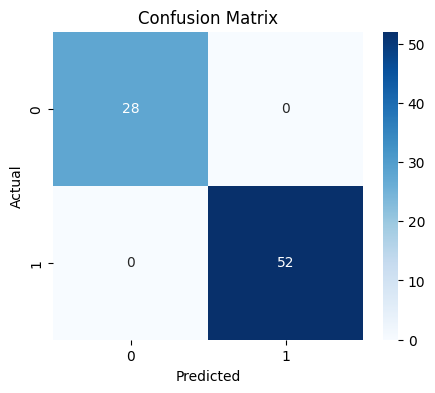

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
import pickle

with open("ckd_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [16]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
4,hemo,0.298740
5,sc,0.230805
2,sg,0.167111
3,al,0.130974
7,dm,0.062649
6,htn,0.035440
1,bp,0.023432
0,age,0.021686
9,appet,0.017778
10,pc,0.010558


In [17]:
feature_importance.to_csv("feature_importance.csv", index=False)